Load Data
-------------------

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# load dataset 'dataset_1980_2020.csv'
raw_data = pd.read_csv('dataset_1980_2020.csv')
raw_data.rename(columns={"Count": "Year"}, inplace=True)
print(raw_data.head())

   Year State  0 to 11  12 to 17  Male  Female  Unknown Gender  White  Black  \
0  1980    AL        0        18    13       5               0      7     10   
1  1981    AL        0        21    19       1               0     13      8   
2  1982    AL        1        19    15       4               0      5     14   
3  1983    AL        2        20    21       1               0      7     15   
4  1984    AL        0        21    19       2               0      7     13   

   Amer. Indian/Alaskan Native  ...  Stranger  Unknown  Firearm  Knife  \
0                            1  ...         4        0       15      3   
1                            0  ...         5        0       13      8   
2                            0  ...         6        0        7      5   
3                            0  ...         4        0       13      7   
4                            0  ...         5        2       12      3   

   Blunt object  Personal  Other/unknown Weapon  One offender involved  \


Pre processing
-------------------

In [3]:
# give states a numerical value
encoder = LabelEncoder()
raw_data["State"] = encoder.fit_transform(raw_data["State"])

# all the feature groups
gender_targets = ["Male", "Female"]
race_targets = ["White", "Black", "Amer. Indian/Alaskan Native", "Asian/Nat. Hawaiian/Pac Isl"]
relation_targets = ["Family", "Acquaintance", "Stranger"]
weapon_targets = ["Firearm", "Knife", "Blunt object", "Personal"]
offenders_targets = ["One offender involved", "Two or more offenders involved"]

all_targets = [gender_targets, race_targets, relation_targets, weapon_targets, offenders_targets]
all_target_names = ["Gender", "Race", "Relation", "Weapon", "Offenders"]

# feature = everything except Year and target variables
all_target_columns = sum(all_targets, [])  # flatten target lists
X = raw_data.drop(columns=all_target_columns + ["Year"])  # drop targets and 'Year' column
features = X.columns  # Define features

y_all = [raw_data[targets] for targets in all_targets]  # target variables

Training and Evaluation
-------------

Random Forest

Male Model Performance:
MAE: 1.36
MSE: 5.46
R² Score: 0.98


Female Model Performance:
MAE: 1.26
MSE: 4.14
R² Score: -0.22




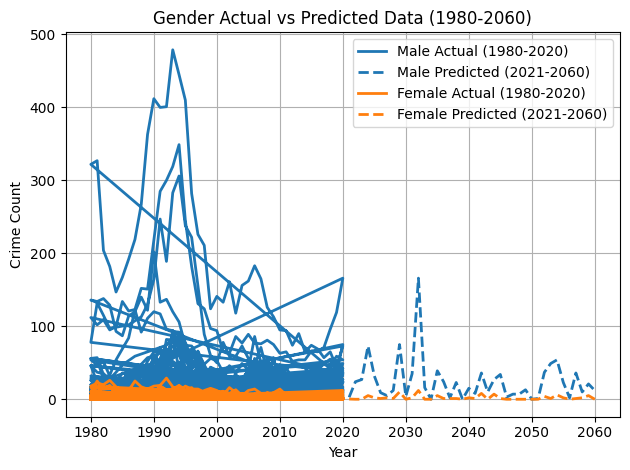

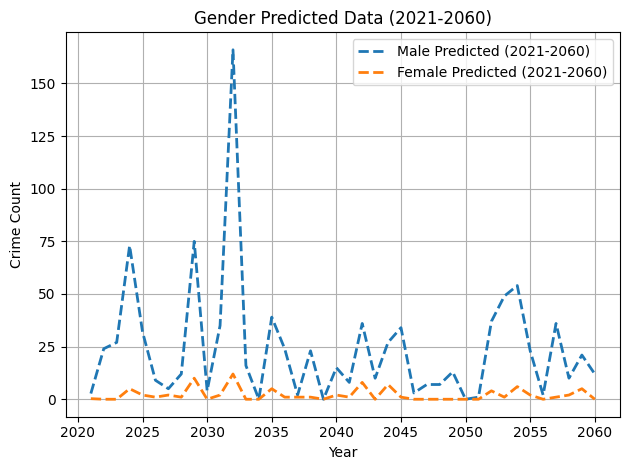

White Model Performance:
MAE: 3.38
MSE: 31.68
R² Score: -0.23


Black Model Performance:
MAE: 3.71
MSE: 45.89
R² Score: 0.81


Amer. Indian/Alaskan Native Model Performance:
MAE: 0.63
MSE: 1.50
R² Score: -13.32


Asian/Nat. Hawaiian/Pac Isl Model Performance:
MAE: 0.35
MSE: 1.35
R² Score: -2.26




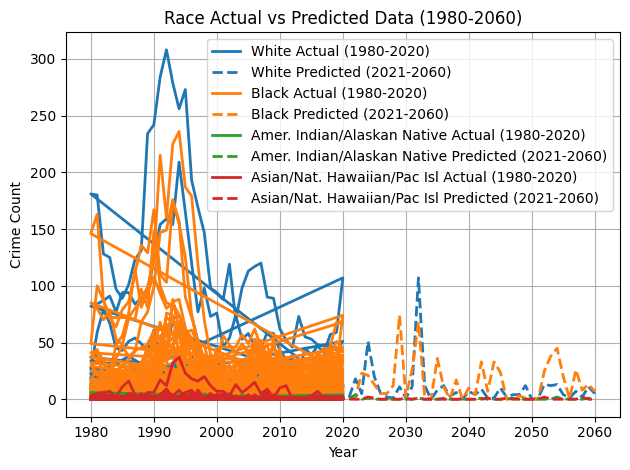

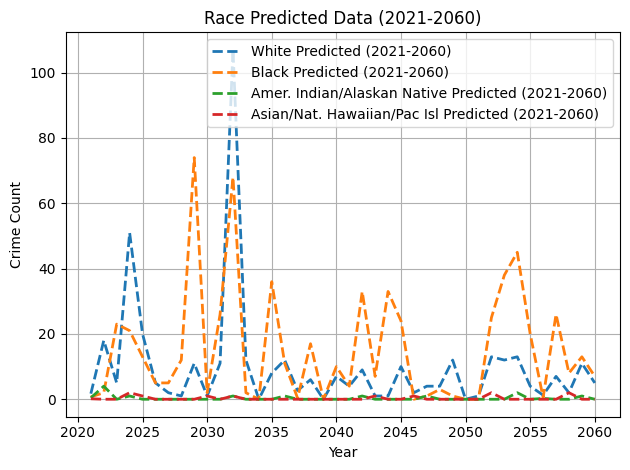

Family Model Performance:
MAE: 1.35
MSE: 4.09
R² Score: 0.03


Acquaintance Model Performance:
MAE: 3.18
MSE: 27.48
R² Score: 0.71


Stranger Model Performance:
MAE: 3.03
MSE: 28.50
R² Score: 0.40




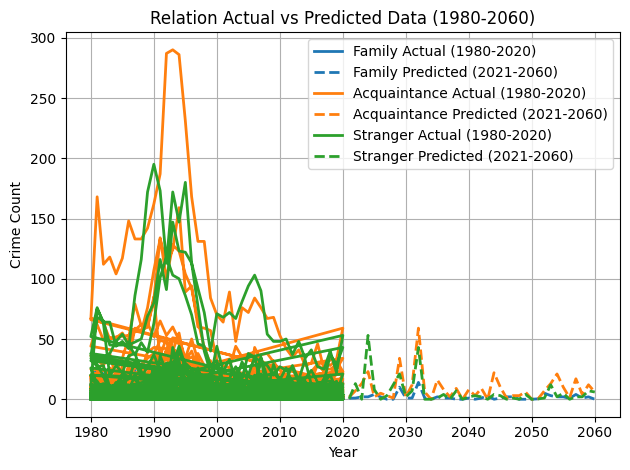

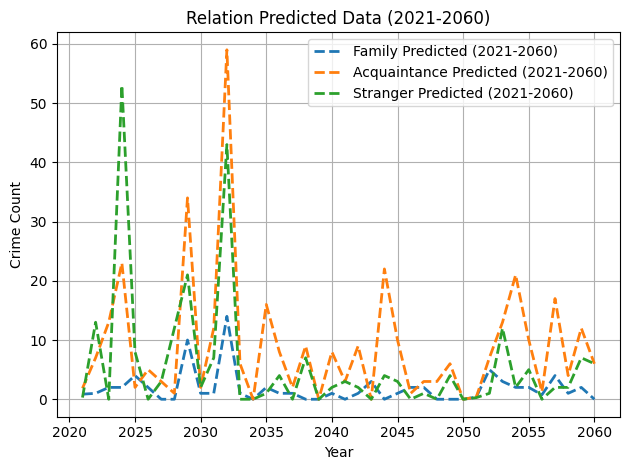

Firearm Model Performance:
MAE: 3.34
MSE: 34.99
R² Score: 0.83


Knife Model Performance:
MAE: 2.04
MSE: 11.39
R² Score: -0.27


Blunt object Model Performance:
MAE: 1.31
MSE: 6.41
R² Score: -0.26


Personal Model Performance:
MAE: 1.43
MSE: 6.87
R² Score: -0.46




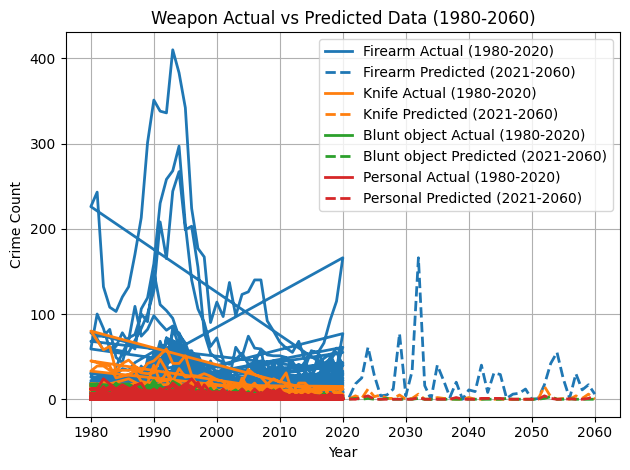

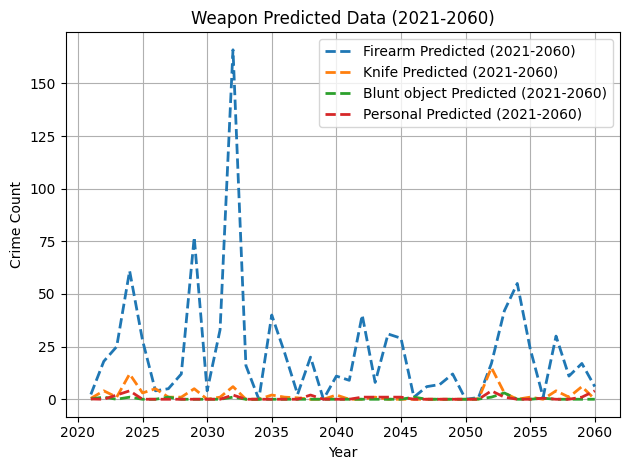

One offender involved Model Performance:
MAE: 3.94
MSE: 43.77
R² Score: 0.51


Two or more offenders involved Model Performance:
MAE: 4.04
MSE: 42.30
R² Score: 0.67




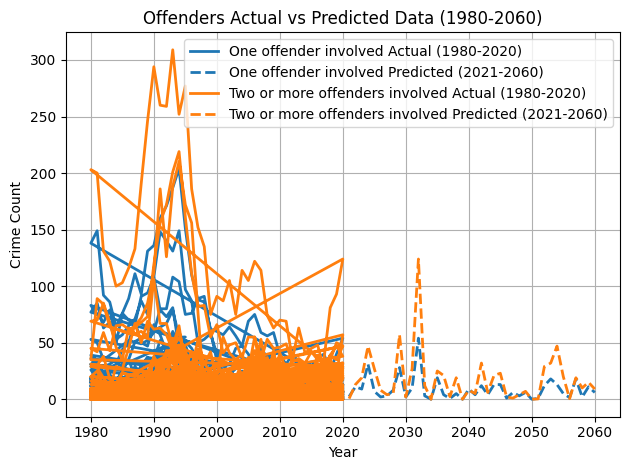

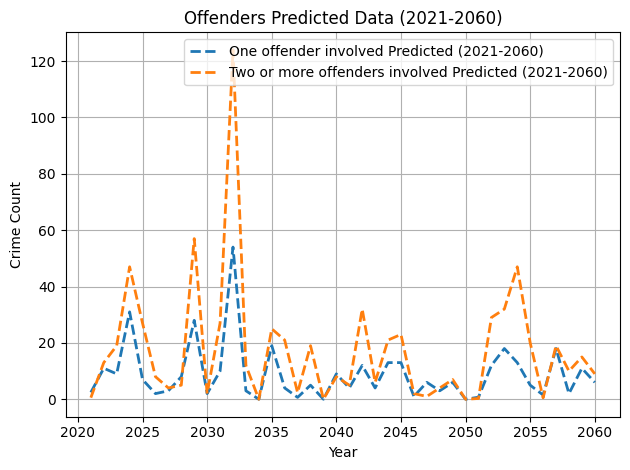

In [4]:
valid_features = [col for col in features if col in raw_data.columns]
valid_features.append('Year')

# prep the future_X data
last_data = raw_data[raw_data["Year"] == 2020].drop(columns=["Year"] + all_target_columns)
future_years = pd.DataFrame({"Year": np.arange(2021, 2061)})
future_X = pd.concat([future_years, pd.DataFrame(np.tile(last_data.values, (len(future_years), 1)), columns=last_data.columns)], axis=1)
# using this to predict
future_X = future_X[valid_features]

# for each target, train and predict
for y, targets, category in zip(y_all, all_targets, all_target_names):

    # split data (80% training, 20% testing)
    train_size = int(len(raw_data) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

    # normalize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # scale the future_X data - excluding year
    future_X_scaled = scaler.transform(future_X[features])

    # train on random forest
    models = {}
    for target in targets:
        model = DecisionTreeRegressor()
        model.fit(X_train_scaled, y_train[target])
        models[target] = model

    # evaluate
    for target, model in models.items():
        y_pred = model.predict(X_test_scaled)
        mae = mean_absolute_error(y_test[target], y_pred)
        mse = mean_squared_error(y_test[target], y_pred)
        r2 = r2_score(y_test[target], y_pred)

        print(f"{target} Model Performance:")
        print(f"MAE: {mae:.2f}")
        print(f"MSE: {mse:.2f}")
        print(f"R² Score: {r2:.2f}")
        print("\n")

    # now predict future values (2021-2060)
    future_predictions = {target: model.predict(future_X_scaled) for target, model in models.items()}

    
    # PLOT

    # atual plot for reference
    for target in targets:
        color = plt.cm.tab10(targets.index(target) % 10)
        actual_data = raw_data[target]
        if actual_data.ndim > 1:
            actual_data = actual_data.mean(axis=1)
        plt.plot(raw_data["Year"], actual_data, label=f"{target} Actual (1980-2020)", color=color, linewidth=2)
        
        target_predictions = future_predictions[target]
        if target_predictions.ndim > 1:
            target_predictions = target_predictions.mean(axis=1)
        if target_predictions.shape[0] != 40:
            target_predictions = target_predictions[:40]
        plt.plot(np.arange(2021, 2061), target_predictions, linestyle="dashed", label=f"{target} Predicted (2021-2060)", color=color, linewidth=2)
    plt.xlabel("Year")
    plt.ylabel("Crime Count")
    plt.title(f"{category} Actual vs Predicted Data (1980-2060)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



    # predicted data plot
    for target in targets:
        target_predictions = future_predictions[target]
        if target_predictions.ndim > 1:
            target_predictions = target_predictions.mean(axis=1)  # average over states
        # target_predictions is (40,)
        if target_predictions.shape[0] != 40:
            target_predictions = target_predictions[:40]
        plt.plot(np.arange(2021, 2061), target_predictions, linestyle="dashed", label=f"{target} Predicted (2021-2060)", linewidth=2)
    plt.xlabel("Year")
    plt.ylabel("Crime Count")
    plt.title(f"{category} Predicted Data (2021-2060)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()




